In [2]:
%matplotlib inline
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as nd

import astropy.io.fits as pyfits
import astropy.units as u

import sep

import grizli
from grizli import utils
print(f'grizli version: {grizli.__version__}')

import msaexp
import msaexp.spectrum
print(f'msaexp version: {msaexp.__version__}')

BASE_URL = 'https://s3.amazonaws.com/msaexp-nirspec/extractions/'
PATH_TO_FILE = BASE_URL + '{root}/{file}'

grizli version: 1.14.2
msaexp version: 0.9.17


In [5]:
from astropy.io import fits
from astropy import units as u
import numpy as np
from matplotlib import pyplot as plt
from astropy.visualization import quantity_support
quantity_support()  # for getting units on the axes below
from specutils import Spectrum

specs = msaexp.spectrum.get_spectra(
    file = "aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits", 
    sx=8, sy=2,
    ny=4, renorm = False
)

https://grizli-cutout.herokuapp.com/nirspec_extractions?file=aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits&output=csv
aurora-gdn02-v4_g140m-f100lp_1914_931951.spec.fits (True) 2.4832  grade=3
aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits (True) 2.4832  grade=3
aurora-gdn02-v4_g395m-f290lp_1914_931951.spec.fits (True) 2.4832  grade=3


(0.0, 20.0)

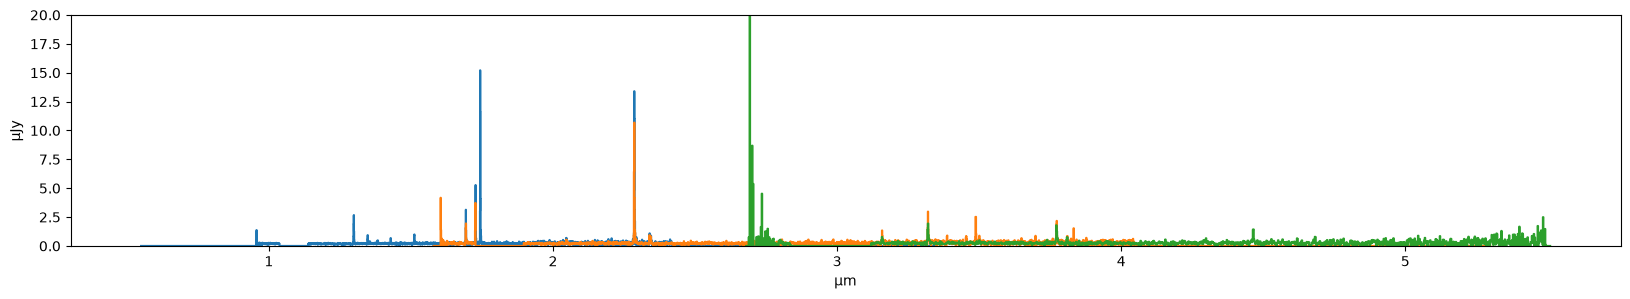

In [10]:
f, ax = plt.subplots(figsize = (20, 3))

for spec in specs:
    ax.step(spec.spectral_axis, spec.flux)
# ax.set_xlim(1.5, 3)
ax.set_ylim(0, 20)

https://grizli-cutout.herokuapp.com/nirspec_extractions?file=aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits&output=csv
aurora-gdn02-v4_g140m-f100lp_1914_931951.spec.fits (True) 2.4832  grade=3
aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits (True) 2.4832  grade=3
aurora-gdn02-v4_g395m-f290lp_1914_931951.spec.fits (True) 2.4832  grade=3
aurora-gdn02-v4_g140m-f100lp_1914_931951.spec.fits  z=2.483  0.28 – 0.69 µm
aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits  z=2.483  0.46 – 1.16 µm
aurora-gdn02-v4_g395m-f290lp_1914_931951.spec.fits  z=2.483  0.79 – 1.58 µm


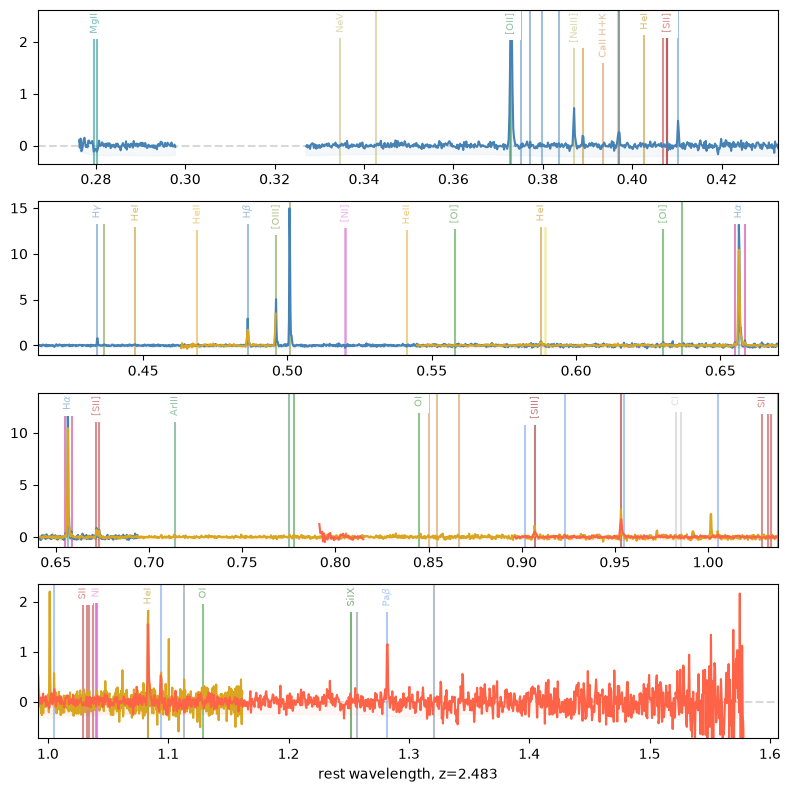

In [9]:
from msaexp import spectrum
import msaexp.utils

result = spectrum.multiplot_spectra(
    file="aurora-gdn02-v4_g235m-f170lp_1914_931951.spec.fits",
    sx=8, sy=2,
    ny=4, renorm = False
)

# Overplot line list
li = msaexp.utils.lines.LineList()
for ax in result['axes']:
    li.add_to_axis(ax, alpha=0.5)

result['axes'][-1].set_xlabel(
    f"rest wavelength, z={result['z']:.3f}"
)

result['fig'].tight_layout(pad=1)